porepy version: 1285edbcbf27528db86ced83eb52dc558288a03d
pp_solvers version: f9551cdf3eaf9c002f8f93fa1d1418bcbcedd14c

In [63]:
import numpy as np

block_linear_system = np.load('linear_system_pT.npy', allow_pickle=True).item()
block_linear_system = block_linear_system[:]

# block_linear_system = block_linear_system[[0, 1, 2, 3, 4, 5]]

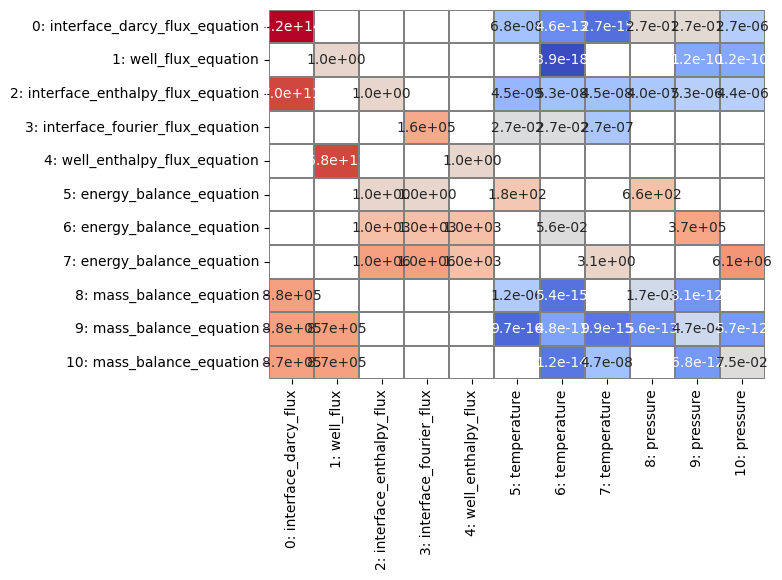

In [64]:
block_linear_system.plot_max()

In [68]:
all_options_dict = {
    "gmres_ksp_type": "gmres",
    "gmres_ksp_pc_side": "right",
    "gmres_ksp_rtol": 1e-12,
    "gmres_ksp_max_it": 100,
    "gmres_ksp_gmres_restart": 100,
    "gmres_ksp_gmres_cgs_refinement_type": "refine_ifneeded",
    "gmres_ksp_gmres_classicalgramschmidt": True,
    "gmres_pc_type": "fieldsplit",
    "gmres_pc_fieldsplit_type": "schur",
    "gmres_pc_fieldsplit_schur_factorization_type": "upper",
    "gmres_pc_fieldsplit_schur_precondition": "selfp",

    "interface_flow_ksp_type": "preonly",
    "interface_flow_pc_type": "ilu",
    
    "fs_interface_energy_ksp_type": "preonly",
    "fs_interface_energy_pc_type": "fieldsplit",
    "fs_interface_energy_pc_fieldsplit_type": "schur",
    "fs_interface_energy_pc_fieldsplit_schur_factorization_type": "upper",
    "fs_interface_energy_pc_fieldsplit_schur_precondition": "selfp",
    
    "interface_energy_ksp_type": "preonly",
    "interface_energy_pc_type": "ilu",
    
    "composite_ksp_type": "preonly",
    "composite_pc_type": "composite",
    "composite_pc_composite_type": "multiplicative",
    
    "fs_cpr0_energy_ksp_type": "preonly",
    "fs_cpr0_energy_pc_type": "fieldsplit",
    # "fs_cpr0_energy_pc_fieldsplit_type": "schur",
    # "fs_cpr0_energy_pc_fieldsplit_schur_factorization_type": "upper",
    # "fs_cpr0_energy_pc_fieldsplit_schur_precondition": "selfp",
    "fs_cpr0_energy_pc_fieldsplit_type": "additive",
    
    "cpr0_energy_ksp_type": "preonly",
    "cpr0_energy_pc_type": "none",
    # "cpr0_energy_pc_type": "hypre",
    # "cpr0_energy_pc_hypre_type": "boomeramg",
    # "cpr0_energy_pc_hypre_boomeramg_strong_threshold": 0.7,
    
    "cpr0_mass_ksp_type": "preonly",
    # "cpr0_mass_pc_type": "none",
    "cpr0_mass_pc_type": "hypre",
    "cpr0_mass_pc_hypre_type": "boomeramg",
    "cpr0_mass_pc_hypre_boomeramg_strong_threshold": 0.7,

    "cpr1_ksp_type": "preonly",
    # 'cpr1_pc_type': 'ilu',
    "cpr1_pc_type": "hypre",
    "cpr1_pc_hypre_type": "ilu",
    'cpr1_pc_hypre_ilu_maxiter': 1,
    'cpr1_pc_hypre_ilu_local_reordering': 1,
    # "cpr1_pc_type": "hypre",
    # "cpr1_pc_hypre_type": 'ilu',

    "gmres_ksp_monitor": None,
    # "fs_interface_energy_ksp_monitor": None,
    # "composite_ksp_monitor": None,
    # 'interface_flow_ksp_monitor': None,
    # 'interface_energy_ksp_monitor': None,
    # "cpr0_mass_ksp_monitor": None,
    # 'cpr0_energy_ksp_monitor': None,
    # "cpr1_ksp_monitor": None,
}
assembly_config = {
    "gmres": {
        "config_type": "fieldsplit_schur",
        "elim_key": "interface_flow",
        "keep_key": "fs_interface_energy",
        "elim_groups": [0, 1],
        "keep_groups": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    },
    "fs_interface_energy": {
        "config_type": "fieldsplit_schur",
        "elim_key": "interface_energy",
        "keep_key": "composite",
        "elim_groups": [2, 3, 4],
        "keep_groups": [5, 6, 7, 8, 9, 10],
    },
    "composite": {
        "config_type": "composite",
        "subsolver_keys": ["fs_cpr0_energy", "cpr1"],
    },
    "fs_cpr0_energy": {
        "config_type": "fieldsplit_common",
        'subsolver_groups': [[5, 6, 7], [8, 9, 10]],
        'subsolver_keys': ['cpr0_energy', 'cpr0_mass'],
        # "config_type": "fieldsplit_schur",
        # "elim_key": "cpr0_energy",
        # "keep_key": "cpr0_mass",
        # "elim_groups": [5, 6, 7],
        # "keep_groups": [8, 9, 10],
    },
}

In [69]:
from pp_solvers import clear_petsc_options, insert_petsc_options, csr_to_petsc
from pp_solvers.options_parsers import assemble_petsc_ksp_pc
from pp_solvers.petsc_solvers import PetscKrylovSolver
from petsc4py import PETSc


petsc_options = clear_petsc_options()
insert_petsc_options(all_options_dict)

petsc_matrices = {}

petsc_ksp = PETSc.KSP().create()

petsc_mat = csr_to_petsc(block_linear_system.mat)
petsc_ksp.setOperators(petsc_mat)
assemble_petsc_ksp_pc(
    ksp=petsc_ksp,
    pc=petsc_ksp.getPC(),
    assembly_config=assembly_config,
    indexer=block_linear_system.indexer,
    key='gmres',
    petsc_matrices=petsc_matrices,
)

# Ensure that all PETSc CLI options are acknowledged.
for key in all_options_dict:
    if not petsc_options.used(key):
        print(
            f"PETSc option {key}: {all_options_dict[key]} is not used. "
            "Check spelling."
        )

solver = PetscKrylovSolver(
    petsc_ksp,
    assembly_config=assembly_config,
    petsc_options=all_options_dict,
)

In [70]:
rhs = block_linear_system.rhs / np.linalg.norm(block_linear_system.rhs)
sol = solver.solve(rhs)
solver.ksp.getConvergedReason()

  Residual norms for gmres_ solve.
  0 KSP Residual norm 1.000000000000e+00
  1 KSP Residual norm 1.547863394782e-01
  2 KSP Residual norm 1.536170857286e-01
  3 KSP Residual norm 8.062344130327e-02
  4 KSP Residual norm 6.845956797747e-02
  5 KSP Residual norm 2.820336807748e-02
  6 KSP Residual norm 2.634489371325e-02
  7 KSP Residual norm 3.650479003297e-03
  8 KSP Residual norm 9.792188677760e-05
  9 KSP Residual norm 1.074096712086e-05
 10 KSP Residual norm 3.365914972522e-06
 11 KSP Residual norm 1.276465334624e-06
 12 KSP Residual norm 2.088816417045e-07
 13 KSP Residual norm 1.005114819773e-08
 14 KSP Residual norm 8.337864859267e-10
 15 KSP Residual norm 3.976026421537e-10
 16 KSP Residual norm 8.928659613088e-12
 17 KSP Residual norm 1.548342915029e-12
 18 KSP Residual norm 4.810615337582e-13


2

# Only energy

In [31]:
block_linear_system = np.load('linear_system_pT.npy', allow_pickle=True).item()
block_linear_system = block_linear_system[:]
block_linear_system = block_linear_system[[5, 6, 7, 8, 9, 10]]

In [25]:
# import scipy.sparse.csgraph

# perm = scipy.sparse.csgraph.reverse_cuthill_mckee(block_linear_system.mat)
# block_linear_system.mat = block_linear_system.mat[perm][:, perm]

In [ ]:
# block_linear_system.matshow(log=False)

KeyboardInterrupt: 

In [32]:
import numpy as np

A = block_linear_system.mat.tocsr()
diag = A.diagonal()

row_max = np.zeros(A.shape[0])
row_sum = np.zeros(A.shape[0])

for i in range(A.shape[0]):
    values = np.abs(A.data[A.indptr[i]:A.indptr[i + 1]])
    row_max[i] = values.max(initial=0.0)
    row_sum[i] = values.sum()

ratio_max = np.divide(
    np.abs(diag), row_max,
    out=np.zeros_like(diag, dtype=float),
    where=row_max != 0
)

ratio_sum = np.divide(
    np.abs(diag), row_sum,
    out=np.zeros_like(diag, dtype=float),
    where=row_sum != 0
)

print("nonfinite entries:", np.count_nonzero(~np.isfinite(A.data)))
print("zero rows:", np.count_nonzero(row_sum == 0))
print("zero diagonal:", np.count_nonzero(diag == 0))
print("min |diag|/row_max:", ratio_max.min())
print("min |diag|/row_sum:", ratio_sum.min())

bad = np.argsort(ratio_max)[:20]
for i in bad:
    print(f'{i=:d} {diag[i]=:.1e}, {row_max[i]=:.1e}, {row_sum[i]=:.1e}, {ratio_max[i]=:.1e}')

nonfinite entries: 0
zero rows: 0
zero diagonal: 0
min |diag|/row_max: 9.72551981919928e-10
min |diag|/row_sum: 4.862782211638232e-10
i=6728 diag[i]=-2.6e-04, row_max[i]=2.7e+05, row_sum[i]=5.3e+05, ratio_max[i]=9.7e-10
i=6737 diag[i]=8.8e-04, row_max[i]=2.8e+05, row_sum[i]=5.6e+05, ratio_max[i]=3.2e-09
i=6971 diag[i]=8.9e-04, row_max[i]=2.7e+05, row_sum[i]=5.4e+05, ratio_max[i]=3.3e-09
i=6741 diag[i]=1.1e-03, row_max[i]=2.7e+05, row_sum[i]=5.5e+05, ratio_max[i]=4.1e-09
i=7337 diag[i]=1.3e-03, row_max[i]=2.8e+05, row_sum[i]=5.5e+05, ratio_max[i]=4.7e-09
i=6841 diag[i]=1.0e-03, row_max[i]=1.9e+05, row_sum[i]=3.7e+05, ratio_max[i]=5.3e-09
i=6713 diag[i]=-8.0e-04, row_max[i]=1.2e+05, row_sum[i]=2.4e+05, ratio_max[i]=6.6e-09
i=6729 diag[i]=-1.0e-03, row_max[i]=1.5e+05, row_sum[i]=2.9e+05, ratio_max[i]=7.1e-09
i=7319 diag[i]=1.5e-03, row_max[i]=2.1e+05, row_sum[i]=4.2e+05, ratio_max[i]=7.2e-09
i=7305 diag[i]=2.0e-03, row_max[i]=2.3e+05, row_sum[i]=4.7e+05, ratio_max[i]=8.3e-09
i=7309 diag[i

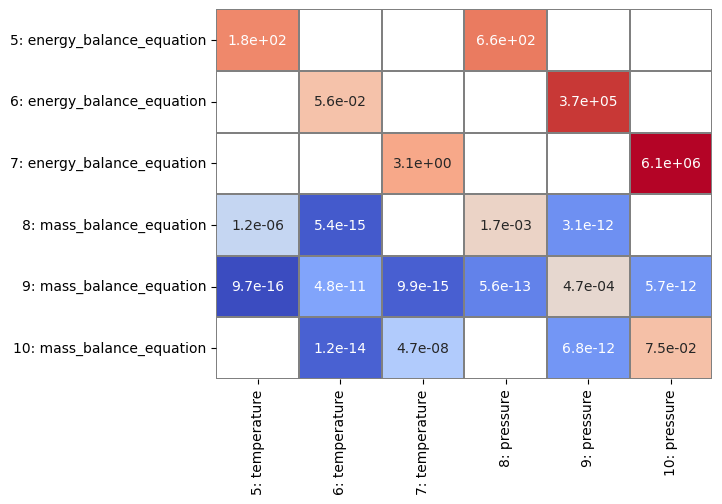

In [33]:
block_linear_system.plot_max()

In [ ]:
all_options_dict = {
    "gmres_ksp_type": "gmres",
    'gmres_ksp_monitor': None,

    # 'gmres_pc_type': 'ilu',

    "gmres_pc_type": "hypre",
    "gmres_pc_hypre_type": "ilu",
    'gmres_pc_hypre_ilu_maxiter': 1,
    'gmres_pc_hypre_ilu_local_reordering': 1,
    # 'gmres_pc_hypre_ilu_level': 0,

    # 'gmres_pc_hypre_ilu_print_level': 2,
    # 'gmres_pc_hypre_ilu_logging': 2,
}
assembly_config = {}

In [59]:
petsc_options = clear_petsc_options()
insert_petsc_options(all_options_dict)

petsc_matrices = {}

petsc_ksp = PETSc.KSP().create()

petsc_mat = csr_to_petsc(block_linear_system.mat)
petsc_ksp.setOperators(petsc_mat)
assemble_petsc_ksp_pc(
    ksp=petsc_ksp,
    pc=petsc_ksp.getPC(),
    assembly_config=assembly_config,
    indexer=block_linear_system.indexer,
    key='gmres',
    petsc_matrices=petsc_matrices,
)

# Ensure that all PETSc CLI options are acknowledged.
for key in all_options_dict:
    if not petsc_options.used(key):
        print(
            f"PETSc option {key}: {all_options_dict[key]} is not used. "
            "Check spelling."
        )

solver = PetscKrylovSolver(
    petsc_ksp,
    assembly_config=assembly_config,
    petsc_options=all_options_dict,
)

In [60]:
rhs = block_linear_system.rhs / np.linalg.norm(block_linear_system.rhs)
sol = solver.solve(rhs)
solver.ksp.getConvergedReason()

  Residual norms for gmres_ solve.
  0 KSP Residual norm 1.777646996432e+03
  1 KSP Residual norm 1.129572761241e+00
  2 KSP Residual norm 7.989674679851e-01
  3 KSP Residual norm 7.972436233324e-01
  4 KSP Residual norm 2.186130036298e-02
  5 KSP Residual norm 1.760425815949e-02


2